# MCDI504 · Machine Learning I
## Semana 04 · Evaluación Sumativa 3 · Fase 4
### `F4_Evaluacion.ipynb`

**Grupo 6:** Luis Díaz Giral, Gonzalo Bouldres y Eduardo Contreras  
**Docente:** Dr. David Ruete Zúñiga  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial · Universidad Andrés Bello

El cuaderno implementa la evaluación y validación del modelo de clasificación seleccionado en Semana 3. El flujo reproduce la partición histórica del proyecto, mantiene el preprocesamiento dentro del proceso de ajuste y genera las evidencias tabulares y gráficas requeridas para Semana 4.


## 0. Entorno, rutas y reproducibilidad

Se fija la semilla del proyecto, se localiza la raíz del repositorio y se inicializan los directorios de salida de Semana 4. En `Semana4/outputs/` y `Semana4/figures/` se conservan únicamente los archivos de control del repositorio antes de generar nuevas evidencias. Las versiones del entorno se registran como metadatos de reproducibilidad. Su comparación con las versiones registradas en Semana 3 es informativa; la continuidad del modelo se valida mediante la configuración, las predicciones y las métricas.


In [1]:
from pathlib import Path
import ast
import hashlib
import json
import platform
import shutil
import time
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
NEG_LABEL = 0
POS_LABEL = 1
UMBRAL_CLASIFICACION = 0.50
np.random.seed(RANDOM_STATE)


def _es_raiz_repo(candidato: Path) -> bool:
    return (
        (candidato / 'Semana3' / 'data' / 'titanic.csv').is_file()
        and (candidato / 'Semana3' / 'outputs').is_dir()
        and (candidato / 'Semana4').is_dir()
    )


def localizar_raiz_repo(inicio: Path) -> Path:
    inicio = inicio.resolve()

    for candidato in [inicio, *inicio.parents]:
        if _es_raiz_repo(candidato):
            return candidato

    candidatos = []
    if inicio.is_dir():
        patrones = ('*', '*/*', '*/*/*')
        for patron in patrones:
            for candidato in inicio.glob(patron):
                if candidato.is_dir() and _es_raiz_repo(candidato):
                    candidatos.append(candidato.resolve())

    candidatos_unicos = sorted(set(candidatos), key=str)
    if len(candidatos_unicos) == 1:
        return candidatos_unicos[0]
    if len(candidatos_unicos) > 1:
        raise FileNotFoundError(
            'Se localizaron varias raíces de proyecto compatibles. '
            'Abra el cuaderno desde la carpeta del repositorio que se desea evaluar.'
        )

    raise FileNotFoundError(
        'No fue posible localizar el repositorio completo. '
        'El cuaderno requiere una raíz que contenga simultáneamente Semana3/ y Semana4/. '
        'Abra Semana4/notebook/F4_Evaluacion.ipynb desde el repositorio completo.'
    )


ROOT = localizar_raiz_repo(Path.cwd())
S3 = ROOT / 'Semana3'
S4 = ROOT / 'Semana4'
DATA_DIR = S4 / 'data'
OUT_DIR = S4 / 'outputs'
FIG_DIR = S4 / 'figures'

for directorio in (DATA_DIR, OUT_DIR, FIG_DIR, S4 / 'docs', S4 / 'informe', S4 / 'notebook'):
    directorio.mkdir(parents=True, exist_ok=True)

for directorio in (OUT_DIR, FIG_DIR):
    for archivo in directorio.iterdir():
        if archivo.is_file() and archivo.name not in {'.gitkeep', 'README.md'}:
            archivo.unlink()

versiones_actuales = {
    'Python': platform.python_version(),
    'NumPy': np.__version__,
    'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__,
    'Matplotlib': matplotlib.__version__,
}
versiones = pd.DataFrame([
    {'Componente': componente, 'Version': version}
    for componente, version in versiones_actuales.items()
])
versiones.to_csv(OUT_DIR / '00_versiones_entorno.csv', index=False)
display(versiones)


,Componente,Version
0,Python,3.12.4
1,NumPy,1.26.4
2,pandas,2.2.2
3,scikit-learn,1.4.2
4,Matplotlib,3.8.4


## 1. Continuidad con Semana 3 y fuente de datos

Se utiliza `Semana3/data/titanic.csv` como fuente del caso de clasificación. El modelo evaluado es el MLP de dos capas ocultas `(100, 50)` seleccionado en Semana 3. La configuración actual se contrasta con la ficha técnica registrada antes de iniciar la validación.


In [2]:
SOURCE_DATA = S3 / 'data' / 'titanic.csv'
S4_DATA = DATA_DIR / 'titanic.csv'
S3_VERSIONS = S3 / 'outputs' / '00_versiones_entorno.csv'
S3_METRICS = S3 / 'outputs' / '23_clf_metricas_mlp.csv'
S3_CONFIG = S3 / 'outputs' / '22_clf_fichas_tecnicas_mlp.csv'
S3_PREDICTIONS = S3 / 'outputs' / '28_clf_predicciones_test.csv'
S3_SPLIT_DIMS = S3 / 'outputs' / '19_clf_dimensiones_split.csv'
S3_SPLIT_BALANCE = S3 / 'outputs' / '21_clf_balance_train_test.csv'

archivos_s3_requeridos = [
    SOURCE_DATA, S3_VERSIONS, S3_METRICS, S3_CONFIG,
    S3_PREDICTIONS, S3_SPLIT_DIMS, S3_SPLIT_BALANCE,
]
faltantes_s3 = [p.relative_to(ROOT).as_posix() for p in archivos_s3_requeridos if not p.exists()]
if faltantes_s3:
    raise FileNotFoundError('Faltan evidencias requeridas de Semana 3: ' + ', '.join(faltantes_s3))

shutil.copy2(SOURCE_DATA, S4_DATA)


def sha256_archivo(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


hash_s3 = sha256_archivo(SOURCE_DATA)
hash_s4 = sha256_archivo(S4_DATA)
if hash_s3 != hash_s4:
    raise RuntimeError('La copia del dataset de Semana 4 no coincide con la fuente de Semana 3.')

MODELO_SELECCIONADO = 'MLP 2 capas ocultas'
ARQUITECTURA_SELECCIONADA = (100, 50)

MODEL_PARAMS = {
    'hidden_layer_sizes': ARQUITECTURA_SELECCIONADA,
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,
    'batch_size': 'auto',
    'learning_rate': 'constant',
    'learning_rate_init': 0.001,
    'max_iter': 500,
    'early_stopping': True,
    'validation_fraction': 0.15,
    'n_iter_no_change': 20,
    'tol': 1e-4,
    'random_state': RANDOM_STATE,
}

versiones_s3 = pd.read_csv(S3_VERSIONS)
versiones_s3_map = dict(zip(versiones_s3['Componente'], versiones_s3['Version'].astype(str)))
control_versiones = pd.DataFrame([
    {
        'Componente': componente,
        'Version_semana3': versiones_s3_map.get(componente, ''),
        'Version_actual': str(versiones_actuales.get(componente, '')),
        'Coincide': str(versiones_s3_map.get(componente, '')) == str(versiones_actuales.get(componente, '')),
    }
    for componente in ['Python', 'NumPy', 'pandas', 'scikit-learn', 'Matplotlib']
])
control_versiones.to_csv(OUT_DIR / '01_control_versiones_semana3.csv', index=False)

metricas_s3 = pd.read_csv(S3_METRICS)
config_s3 = pd.read_csv(S3_CONFIG)
fila_metricas_s3 = metricas_s3.loc[metricas_s3['Modelo'] == MODELO_SELECCIONADO].copy()
fila_config_s3 = config_s3.loc[config_s3['Modelo'] == MODELO_SELECCIONADO].copy()
if len(fila_metricas_s3) != 1 or len(fila_config_s3) != 1:
    raise RuntimeError('No se pudo identificar de forma unívoca el modelo seleccionado en Semana 3.')

cfg = fila_config_s3.iloc[0]
config_checks = [
    ('hidden_layer_sizes', ast.literal_eval(str(cfg['hidden_layer_sizes'])) == MODEL_PARAMS['hidden_layer_sizes']),
    ('activation', str(cfg['activation']) == MODEL_PARAMS['activation']),
    ('solver', str(cfg['solver']) == MODEL_PARAMS['solver']),
    ('alpha', np.isclose(float(cfg['alpha']), MODEL_PARAMS['alpha'])),
    ('batch_size', str(cfg['batch_size']) == str(MODEL_PARAMS['batch_size'])),
    ('learning_rate', str(cfg['learning_rate']) == MODEL_PARAMS['learning_rate']),
    ('learning_rate_init', np.isclose(float(cfg['learning_rate_init']), MODEL_PARAMS['learning_rate_init'])),
    ('max_iter', int(cfg['max_iter']) == MODEL_PARAMS['max_iter']),
    ('early_stopping', (str(cfg['early_stopping']).strip().lower() in {'true', '1'}) == MODEL_PARAMS['early_stopping']),
    ('validation_fraction', np.isclose(float(cfg['validation_fraction']), MODEL_PARAMS['validation_fraction'])),
    ('n_iter_no_change', int(cfg['n_iter_no_change']) == MODEL_PARAMS['n_iter_no_change']),
    ('tol', np.isclose(float(cfg['tol']), MODEL_PARAMS['tol'])),
    ('random_state', int(cfg['random_state']) == MODEL_PARAMS['random_state']),
]
control_configuracion = pd.DataFrame(config_checks, columns=['Parametro', 'Coincide_semana3'])
control_configuracion.to_csv(OUT_DIR / '02_verificacion_configuracion_semana3.csv', index=False)
if not control_configuracion['Coincide_semana3'].all():
    raise RuntimeError('La configuración del modelo no coincide con la ficha técnica de Semana 3.')

proveniencia = pd.DataFrame([
    {'Elemento': 'Dataset_fuente', 'Valor': SOURCE_DATA.relative_to(ROOT).as_posix()},
    {'Elemento': 'Dataset_semana4', 'Valor': S4_DATA.relative_to(ROOT).as_posix()},
    {'Elemento': 'SHA256_dataset', 'Valor': hash_s4},
    {'Elemento': 'Modelo_seleccionado_semana3', 'Valor': MODELO_SELECCIONADO},
    {'Elemento': 'Arquitectura', 'Valor': str(ARQUITECTURA_SELECCIONADA)},
    {'Elemento': 'Random_state', 'Valor': RANDOM_STATE},
])
proveniencia.to_csv(OUT_DIR / '03_proveniencia_semana3.csv', index=False)

display(control_versiones)
display(control_configuracion)
display(proveniencia)


,Componente,Version_semana3,Version_actual,Coincide
0,Python,3.12.4,3.12.4,True
1,NumPy,1.26.4,1.26.4,True
2,pandas,2.2.2,2.2.2,True
3,scikit-learn,1.4.2,1.4.2,True
4,Matplotlib,3.8.4,3.8.4,True


,Parametro,Coincide_semana3
0,hidden_layer_sizes,True
1,activation,True
2,solver,True
3,alpha,True
4,batch_size,True
5,learning_rate,True
6,learning_rate_init,True
7,max_iter,True
8,early_stopping,True
9,validation_fraction,True


,Elemento,Valor
0,Dataset_fuente,Semana3/data/titanic.csv
1,Dataset_semana4,Semana4/data/titanic.csv
2,SHA256_dataset,81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86...
3,Modelo_seleccionado_semana3,MLP 2 capas ocultas
4,Arquitectura,"(100, 50)"
5,Random_state,42


## 2. Definición analítica y auditoría del dataset

El problema corresponde a clasificación binaria de `survived`. La clase positiva es `1` (`sobrevivió`). Se conservan los siete predictores definidos en Semana 3 y se excluyen variables redundantes, derivadas o con fuga directa de información respecto de la variable objetivo.


,Variable,Rol,Tipo,Tratamiento,Justificacion
0,survived,Objetivo,Binaria,Sin transformación,Variable objetivo del caso
1,pclass,Predictor,Numérica ordinal,Imputación mediana + estandarización,Predictor definido en Semana 3
2,age,Predictor,Numérica continua,Imputación mediana + estandarización,Predictor definido en Semana 3
3,sibsp,Predictor,Numérica discreta,Imputación mediana + estandarización,Predictor definido en Semana 3
4,parch,Predictor,Numérica discreta,Imputación mediana + estandarización,Predictor definido en Semana 3
5,fare,Predictor,Numérica continua,Imputación mediana + estandarización,Predictor definido en Semana 3
6,sex,Predictor,Categórica,Imputación moda + One-Hot Encoding,Predictor definido en Semana 3
7,embarked,Predictor,Categórica,Imputación moda + One-Hot Encoding,Predictor definido en Semana 3
8,alive,Excluida,Categórica,No utilizada,Fuga directa respecto de survived
9,class,Excluida,Categórica,No utilizada,Redundancia con pclass


,Elemento,Valor
0,Filas,891
1,Columnas_originales,15
2,Predictores_seleccionados,7
3,Variable_objetivo,survived
4,Clase_positiva,1
5,Clase_negativa,0
6,Filas_exactamente_repetidas_dataset,107
7,Filas_repetidas_variables_modelo_y_objetivo,111


,Variable,Valores_faltantes
0,pclass,0
1,age,177
2,sibsp,0
3,parch,0
4,fare,0
5,sex,0
6,embarked,2
7,survived,0


,Clase,Frecuencia,Porcentaje
0,0,549,61.616162
1,1,342,38.383838


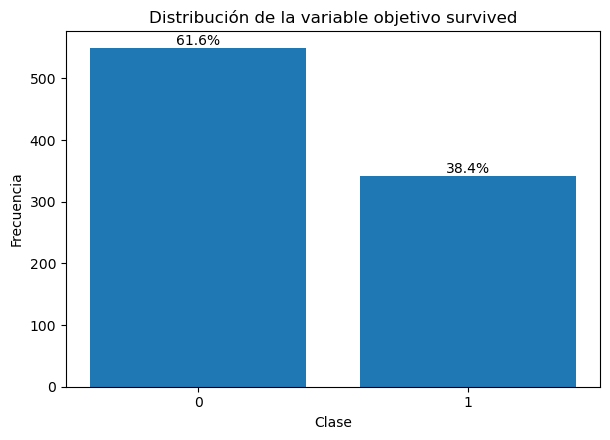

In [3]:
clf_df = pd.read_csv(S4_DATA)
TARGET = 'survived'
NUM_FEATURES = ['pclass', 'age', 'sibsp', 'parch', 'fare']
CAT_FEATURES = ['sex', 'embarked']
FEATURES = NUM_FEATURES + CAT_FEATURES

columnas_requeridas = FEATURES + [TARGET]
faltantes_columnas = [c for c in columnas_requeridas if c not in clf_df.columns]
if faltantes_columnas:
    raise RuntimeError('Faltan columnas requeridas: ' + ', '.join(faltantes_columnas))
if clf_df[TARGET].isna().any():
    raise RuntimeError('La variable objetivo contiene valores faltantes.')
if set(pd.unique(clf_df[TARGET])) != {NEG_LABEL, POS_LABEL}:
    raise RuntimeError('La variable objetivo debe contener exclusivamente las clases 0 y 1.')

variables_modelo = pd.DataFrame([
    {'Variable':'survived', 'Rol':'Objetivo', 'Tipo':'Binaria', 'Tratamiento':'Sin transformación', 'Justificacion':'Variable objetivo del caso'},
    {'Variable':'pclass', 'Rol':'Predictor', 'Tipo':'Numérica ordinal', 'Tratamiento':'Imputación mediana + estandarización', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'age', 'Rol':'Predictor', 'Tipo':'Numérica continua', 'Tratamiento':'Imputación mediana + estandarización', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'sibsp', 'Rol':'Predictor', 'Tipo':'Numérica discreta', 'Tratamiento':'Imputación mediana + estandarización', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'parch', 'Rol':'Predictor', 'Tipo':'Numérica discreta', 'Tratamiento':'Imputación mediana + estandarización', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'fare', 'Rol':'Predictor', 'Tipo':'Numérica continua', 'Tratamiento':'Imputación mediana + estandarización', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'sex', 'Rol':'Predictor', 'Tipo':'Categórica', 'Tratamiento':'Imputación moda + One-Hot Encoding', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'embarked', 'Rol':'Predictor', 'Tipo':'Categórica', 'Tratamiento':'Imputación moda + One-Hot Encoding', 'Justificacion':'Predictor definido en Semana 3'},
    {'Variable':'alive', 'Rol':'Excluida', 'Tipo':'Categórica', 'Tratamiento':'No utilizada', 'Justificacion':'Fuga directa respecto de survived'},
    {'Variable':'class', 'Rol':'Excluida', 'Tipo':'Categórica', 'Tratamiento':'No utilizada', 'Justificacion':'Redundancia con pclass'},
    {'Variable':'embark_town', 'Rol':'Excluida', 'Tipo':'Categórica', 'Tratamiento':'No utilizada', 'Justificacion':'Redundancia con embarked'},
    {'Variable':'who', 'Rol':'Excluida', 'Tipo':'Categórica', 'Tratamiento':'No utilizada', 'Justificacion':'Variable derivada'},
    {'Variable':'adult_male', 'Rol':'Excluida', 'Tipo':'Binaria', 'Tratamiento':'No utilizada', 'Justificacion':'Variable derivada'},
    {'Variable':'alone', 'Rol':'Excluida', 'Tipo':'Binaria', 'Tratamiento':'No utilizada', 'Justificacion':'Variable derivada'},
    {'Variable':'deck', 'Rol':'Excluida', 'Tipo':'Categórica', 'Tratamiento':'No utilizada', 'Justificacion':'Alta proporción de valores faltantes'},
])

perfil_dataset = pd.DataFrame({
    'Elemento': [
        'Filas', 'Columnas_originales', 'Predictores_seleccionados',
        'Variable_objetivo', 'Clase_positiva', 'Clase_negativa',
        'Filas_exactamente_repetidas_dataset', 'Filas_repetidas_variables_modelo_y_objetivo'
    ],
    'Valor': [
        len(clf_df), clf_df.shape[1], len(FEATURES), TARGET, POS_LABEL, NEG_LABEL,
        int(clf_df.duplicated().sum()),
        int(clf_df[FEATURES + [TARGET]].duplicated().sum()),
    ],
})

control_nulos = (
    clf_df[columnas_requeridas].isna().sum()
    .rename('Valores_faltantes').reset_index().rename(columns={'index':'Variable'})
)

distribucion_clases = (
    clf_df[TARGET].value_counts().sort_index().rename_axis('Clase')
    .reset_index(name='Frecuencia')
)
distribucion_clases['Porcentaje'] = 100 * distribucion_clases['Frecuencia'] / distribucion_clases['Frecuencia'].sum()

variables_modelo.to_csv(OUT_DIR / '04_diccionario_variables.csv', index=False)
perfil_dataset.to_csv(OUT_DIR / '05_perfil_dataset.csv', index=False)
control_nulos.to_csv(OUT_DIR / '06_control_nulos.csv', index=False)
distribucion_clases.to_csv(OUT_DIR / '07_distribucion_clases.csv', index=False)

display(variables_modelo)
display(perfil_dataset)
display(control_nulos)
display(distribucion_clases)

fig, ax = plt.subplots(figsize=(6.2, 4.5))
barras = ax.bar(distribucion_clases['Clase'].astype(str), distribucion_clases['Frecuencia'])
for barra, porcentaje in zip(barras, distribucion_clases['Porcentaje']):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(), f'{porcentaje:.1f}%', ha='center', va='bottom')
ax.set(title='Distribución de la variable objetivo survived', xlabel='Clase', ylabel='Frecuencia')
fig.tight_layout()
fig.savefig(FIG_DIR / '01_distribucion_clases.png', dpi=180, bbox_inches='tight')
plt.show()


## 3. Partición del proyecto

Se reproduce la partición estratificada 80/20 de Semana 3 con `random_state=42`. Esta partición Hold-Out ya participó en la comparación de arquitecturas realizada en Semana 3; por tanto, en Semana 4 se utiliza como evidencia histórica de desempeño y continuidad, no como una nueva muestra independiente posterior a la selección del modelo. No se reajustan arquitectura, hiperparámetros ni umbral utilizando el conjunto de prueba. La estimación de estabilidad se realiza exclusivamente sobre el subconjunto de entrenamiento mediante K-Fold estratificado.


In [4]:
X = clf_df[FEATURES].copy()
y = clf_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

if not set(X_train.index).isdisjoint(set(X_test.index)):
    raise RuntimeError('Las particiones de entrenamiento y prueba no son disjuntas.')
if set(X_train.index).union(set(X_test.index)) != set(clf_df.index):
    raise RuntimeError('La partición no cubre todas las observaciones del dataset.')

split_dimensiones = pd.DataFrame({
    'Objeto': ['X_train', 'X_test', 'y_train', 'y_test'],
    'Filas': [len(X_train), len(X_test), len(y_train), len(y_test)],
})

balance_particiones = pd.concat([
    y_train.value_counts(normalize=True).sort_index().rename('Train'),
    y_test.value_counts(normalize=True).sort_index().rename('Test'),
], axis=1).reset_index().rename(columns={'index':'Clase'})

indices_split = pd.DataFrame({
    'Indice_original': clf_df.index,
    'Particion': np.where(clf_df.index.isin(X_test.index), 'test', 'train'),
    'Clase_real': y.values,
}).sort_values('Indice_original')

split_dimensiones.to_csv(OUT_DIR / '08_dimensiones_split.csv', index=False)
balance_particiones.to_csv(OUT_DIR / '09_balance_clases_split.csv', index=False)
indices_split.to_csv(OUT_DIR / '10_indices_split.csv', index=False)

display(split_dimensiones)
display(balance_particiones)

# Verificación de continuidad de dimensiones y proporciones de clase con Semana 3.
split_dimensiones_s3 = pd.read_csv(S3_SPLIT_DIMS)
balance_particiones_s3 = pd.read_csv(S3_SPLIT_BALANCE)

map_dim_s4 = dict(zip(split_dimensiones['Objeto'], split_dimensiones['Filas']))
map_dim_s3 = dict(zip(split_dimensiones_s3['Objeto'], split_dimensiones_s3['Filas']))
controles_dimensiones = []
for objeto in ['X_train', 'X_test', 'y_train', 'y_test']:
    controles_dimensiones.append({
        'Control': f'Filas_{objeto}',
        'Valor_semana3': int(map_dim_s3[objeto]),
        'Valor_semana4': int(map_dim_s4[objeto]),
        'Coincide': int(map_dim_s3[objeto]) == int(map_dim_s4[objeto]),
    })

columnas_balance_s3 = {c.lower(): c for c in balance_particiones_s3.columns}
if not {'train', 'test'}.issubset(columnas_balance_s3):
    raise RuntimeError('La evidencia de balance de Semana 3 no contiene las columnas train y test esperadas.')
columnas_clase_s3 = [c for c in balance_particiones_s3.columns if c.lower() not in {'train', 'test'}]
if len(columnas_clase_s3) != 1:
    raise RuntimeError('No se pudo identificar de forma unívoca la columna de clase en el balance de Semana 3.')
columna_clase_s3 = columnas_clase_s3[0]
balance_s3_norm = balance_particiones_s3.rename(columns={
    columna_clase_s3: 'Clase',
    columnas_balance_s3['train']: 'Train',
    columnas_balance_s3['test']: 'Test',
})[['Clase', 'Train', 'Test']].sort_values('Clase').reset_index(drop=True)
columnas_clase_s4 = [c for c in balance_particiones.columns if c not in {'Train', 'Test'}]
if len(columnas_clase_s4) != 1:
    raise RuntimeError('No se pudo identificar de forma unívoca la columna de clase en el balance de Semana 4.')
balance_s4_norm = balance_particiones.rename(columns={columnas_clase_s4[0]: 'Clase'})[['Clase', 'Train', 'Test']].sort_values('Clase').reset_index(drop=True)

if not np.array_equal(balance_s3_norm['Clase'].to_numpy(), balance_s4_norm['Clase'].to_numpy()):
    raise RuntimeError('Las clases del split no coinciden con Semana 3.')
for columna in ['Train', 'Test']:
    coincide = np.allclose(
        balance_s3_norm[columna].to_numpy(dtype=float),
        balance_s4_norm[columna].to_numpy(dtype=float),
        rtol=0.0, atol=1e-12,
    )
    controles_dimensiones.append({
        'Control': f'Proporcion_{columna}',
        'Valor_semana3': ';'.join(f'{v:.12f}' for v in balance_s3_norm[columna]),
        'Valor_semana4': ';'.join(f'{v:.12f}' for v in balance_s4_norm[columna]),
        'Coincide': bool(coincide),
    })

control_split_semana3 = pd.DataFrame(controles_dimensiones)
if not control_split_semana3['Coincide'].all():
    raise RuntimeError('La partición reproducida en Semana 4 no coincide con la evidencia archivada de Semana 3.')
control_split_semana3.to_csv(OUT_DIR / '10b_verificacion_split_semana3.csv', index=False)
display(control_split_semana3)


,Objeto,Filas
0,X_train,712
1,X_test,179
2,y_train,712
3,y_test,179


,survived,Train,Test
0,0,0.616573,0.614525
1,1,0.383427,0.385475


,Control,Valor_semana3,Valor_semana4,Coincide
0,Filas_X_train,712,712,True
1,Filas_X_test,179,179,True
2,Filas_y_train,712,712,True
3,Filas_y_test,179,179,True
4,Proporcion_Train,0.616573033708;0.383426966292,0.616573033708;0.383426966292,True
5,Proporcion_Test,0.614525139665;0.385474860335,0.614525139665;0.385474860335,True


## 4. Métricas, pipeline y protocolo de validación

Las métricas principales son accuracy, precision, recall y F1-score. Se incorporan balanced accuracy, especificidad, ROC-AUC y average precision como evidencia complementaria. La clase positiva se fija en `1`.

El preprocesamiento y el MLP se integran en un único `Pipeline`. Para la estabilidad se utiliza K-Fold estratificado con `k=5`: cada ajuste aprende imputación, codificación y escalamiento exclusivamente con el subconjunto de entrenamiento del fold. Hold-Out requiere un ajuste y Leave-One-Out requeriría un ajuste por observación de entrenamiento; K-Fold proporciona un compromiso entre repetición del ajuste y estabilidad de las métricas para este conjunto de datos.

El umbral de clasificación se conserva en `0.50`, consistente con la regla de decisión utilizada por `MLPClassifier.predict` en este problema binario y con la continuidad de Semana 3. No se optimiza con el conjunto de prueba porque el caso no define una función de costos que justifique desplazarlo. Semana 4 valida el modelo ya seleccionado; no realiza una nueva selección comparativa entre arquitecturas.


In [5]:
diccionario_metricas = pd.DataFrame([
    {'Metrica':'Accuracy', 'Definicion':'(TP + TN) / (TP + TN + FP + FN)', 'Referencia_clase':'Ambas clases'},
    {'Metrica':'Precision', 'Definicion':'TP / (TP + FP)', 'Referencia_clase':'Positiva = 1'},
    {'Metrica':'Recall', 'Definicion':'TP / (TP + FN)', 'Referencia_clase':'Positiva = 1'},
    {'Metrica':'F1_score', 'Definicion':'2 * Precision * Recall / (Precision + Recall)', 'Referencia_clase':'Positiva = 1'},
    {'Metrica':'Balanced_accuracy', 'Definicion':'Promedio de sensibilidad y especificidad', 'Referencia_clase':'Ambas clases'},
    {'Metrica':'Especificidad', 'Definicion':'TN / (TN + FP)', 'Referencia_clase':'Negativa = 0'},
    {'Metrica':'ROC_AUC', 'Definicion':'Área bajo la curva ROC', 'Referencia_clase':'Positiva = 1'},
    {'Metrica':'Average_precision', 'Definicion':'Resumen de precision-recall ponderado por incrementos de recall', 'Referencia_clase':'Positiva = 1'},
])


def construir_pipeline() -> Pipeline:
    pipeline_numerico = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ('num', pipeline_numerico, NUM_FEATURES),
        ('cat', pipeline_categorico, CAT_FEATURES),
    ], remainder='drop', verbose_feature_names_out=False)
    modelo = MLPClassifier(**MODEL_PARAMS)
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', modelo),
    ])


def probabilidad_clase_positiva(pipeline: Pipeline, X_data: pd.DataFrame) -> np.ndarray:
    probabilidades = pipeline.predict_proba(X_data)
    clases = pipeline.named_steps['model'].classes_
    posiciones = np.where(clases == POS_LABEL)[0]
    if len(posiciones) != 1:
        raise RuntimeError('No se identificó de forma unívoca la columna de probabilidad de la clase positiva.')
    return probabilidades[:, int(posiciones[0])]


configuracion_evaluacion = pd.DataFrame([
    {'Parametro':'Modelo', 'Valor':MODELO_SELECCIONADO},
    {'Parametro':'hidden_layer_sizes', 'Valor':str(ARQUITECTURA_SELECCIONADA)},
    {'Parametro':'activation', 'Valor':MODEL_PARAMS['activation']},
    {'Parametro':'solver', 'Valor':MODEL_PARAMS['solver']},
    {'Parametro':'alpha', 'Valor':MODEL_PARAMS['alpha']},
    {'Parametro':'learning_rate_init', 'Valor':MODEL_PARAMS['learning_rate_init']},
    {'Parametro':'max_iter', 'Valor':MODEL_PARAMS['max_iter']},
    {'Parametro':'early_stopping', 'Valor':MODEL_PARAMS['early_stopping']},
    {'Parametro':'validation_fraction', 'Valor':MODEL_PARAMS['validation_fraction']},
    {'Parametro':'n_iter_no_change', 'Valor':MODEL_PARAMS['n_iter_no_change']},
    {'Parametro':'Tecnica_validacion', 'Valor':'StratifiedKFold'},
    {'Parametro':'n_splits', 'Valor':N_SPLITS},
    {'Parametro':'shuffle', 'Valor':True},
    {'Parametro':'random_state', 'Valor':RANDOM_STATE},
    {'Parametro':'Clase_positiva', 'Valor':POS_LABEL},
    {'Parametro':'Umbral_clasificacion', 'Valor':UMBRAL_CLASIFICACION},
])

protocolo_validacion = pd.DataFrame([
    {'Tecnica':'Hold-Out histórico 80/20', 'Ajustes_externos':1, 'Conjunto_evaluado':'test', 'Uso_semana4':'Evaluación y continuidad con Semana 3'},
    {'Tecnica':'K-Fold estratificado', 'Ajustes_externos':N_SPLITS, 'Conjunto_evaluado':'train', 'Uso_semana4':'Estimación de estabilidad'},
    {'Tecnica':'Leave-One-Out', 'Ajustes_externos':len(X_train), 'Conjunto_evaluado':'train', 'Uso_semana4':'No implementado; referencia de costo'},
])

diccionario_metricas.to_csv(OUT_DIR / '11_diccionario_metricas.csv', index=False)
configuracion_evaluacion.to_csv(OUT_DIR / '12_configuracion_evaluacion.csv', index=False)
protocolo_validacion.to_csv(OUT_DIR / '13_protocolo_validacion.csv', index=False)

display(diccionario_metricas)
display(configuracion_evaluacion)
display(protocolo_validacion)


,Metrica,Definicion,Referencia_clase
0,Accuracy,(TP + TN) / (TP + TN + FP + FN),Ambas clases
1,Precision,TP / (TP + FP),Positiva = 1
2,Recall,TP / (TP + FN),Positiva = 1
3,F1_score,2 * Precision * Recall / (Precision + Recall),Positiva = 1
4,Balanced_accuracy,Promedio de sensibilidad y especificidad,Ambas clases
5,Especificidad,TN / (TN + FP),Negativa = 0
6,ROC_AUC,Área bajo la curva ROC,Positiva = 1
7,Average_precision,Resumen de precision-recall ponderado por incr...,Positiva = 1


,Parametro,Valor
0,Modelo,MLP 2 capas ocultas
1,hidden_layer_sizes,"(100, 50)"
2,activation,relu
3,solver,adam
4,alpha,0.0001
5,learning_rate_init,0.001
6,max_iter,500
7,early_stopping,True
8,validation_fraction,0.15
9,n_iter_no_change,20


,Tecnica,Ajustes_externos,Conjunto_evaluado,Uso_semana4
0,Hold-Out histórico 80/20,1,test,Evaluación y continuidad con Semana 3
1,K-Fold estratificado,5,train,Estimación de estabilidad
2,Leave-One-Out,712,train,No implementado; referencia de costo


## 5. Validación cruzada K-Fold estratificada

La validación se ejecuta únicamente sobre `X_train` y `y_train`. Cada observación de entrenamiento recibe una predicción out-of-fold exactamente una vez. Se registran métricas por fold, estabilidad, matrices de confusión, balance de clases, advertencias de entrenamiento y costo computacional de la corrida.


,Fold,N_train,N_validacion,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,FPR,...,ROC_AUC,Average_precision,TN,FP,FN,TP,Iteraciones_MLP,Best_validation_score,Loss_final,Tiempo_ajuste_segundos
0,1,569,143,0.832168,0.816327,0.727273,0.769231,0.812500,0.897727,0.102273,...,0.856095,0.846971,79,9,15,40,75,0.872093,0.353108,0.296248
1,2,569,143,0.818182,0.853659,0.636364,0.729167,0.784091,0.931818,0.068182,...,0.833884,0.832845,82,6,20,35,55,0.860465,0.346086,0.233882
2,3,570,142,0.845070,0.883721,0.690909,0.775510,0.816719,0.942529,0.057471,...,0.886834,0.869787,82,5,17,38,43,0.860465,0.393975,0.166759
3,4,570,142,0.823944,0.773585,0.759259,0.766355,0.811448,0.863636,0.136364,...,0.861216,0.848441,76,12,13,41,56,0.930233,0.376179,0.213772
4,5,570,142,0.809859,0.846154,0.611111,0.709677,0.771465,0.931818,0.068182,...,0.873316,0.798611,82,6,21,33,38,0.825581,0.362890,0.184955


,Metrica,Promedio,Desv_estandar_poblacional,Desv_estandar_muestral,Minimo,Maximo,Rango
0,Accuracy,0.825845,0.012062,0.013486,0.809859,0.845070,0.035211
1,Precision,0.834689,0.037326,0.041732,0.773585,0.883721,0.110136
2,Recall,0.684983,0.055066,0.061566,0.611111,0.759259,0.148148
3,F1_score,0.749988,0.025877,0.028931,0.709677,0.775510,0.065833
4,Balanced_accuracy,0.799244,0.018063,0.020195,0.771465,0.816719,0.045254
5,Especificidad,0.913506,0.029151,0.032592,0.863636,0.942529,0.078892
6,FPR,0.086494,0.029151,0.032592,0.057471,0.136364,0.078892
7,FNR,0.315017,0.055066,0.061566,0.240741,0.388889,0.148148
8,ROC_AUC,0.862269,0.017722,0.019814,0.833884,0.886834,0.052950
9,Average_precision,0.839331,0.023534,0.026311,0.798611,0.869787,0.071176


,Pred_0_no_sobrevivio,Pred_1_sobrevivio
Real_0_no_sobrevivio,401,38
Real_1_sobrevivio,86,187


,Indicador,Valor,Unidad
0,Ajustes_externos_KFold,5.000000,ajustes
1,Tiempo_total_KFold,1.223788,segundos
2,Tiempo_promedio_ajuste_fold,0.219123,segundos
3,Ajustes_teoricos_LOOCV,712.000000,ajustes
4,Ajustes_HoldOut,1.000000,ajustes


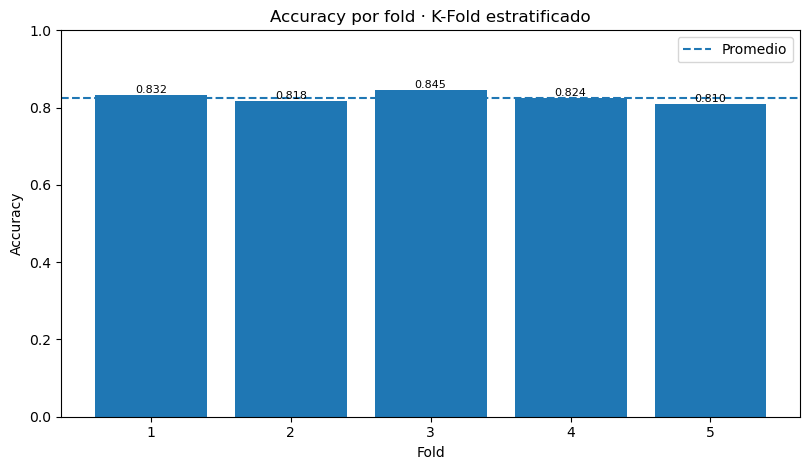

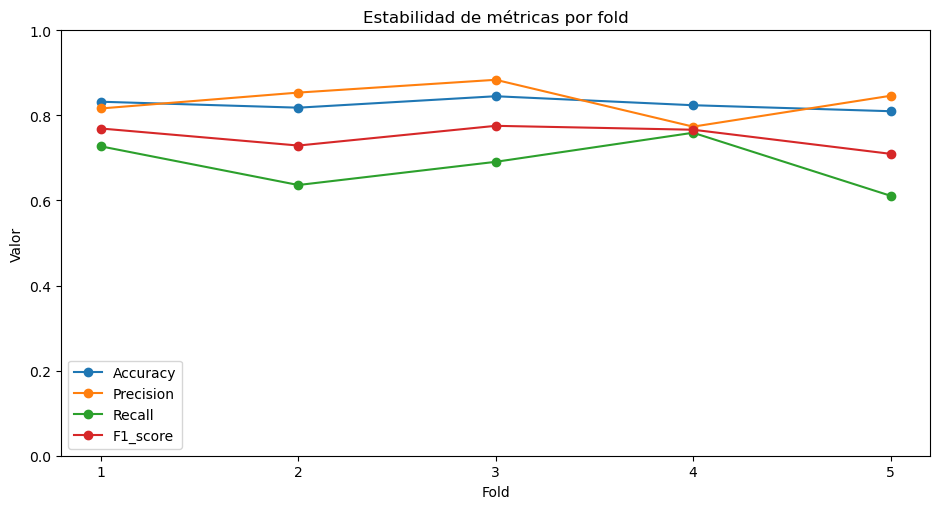

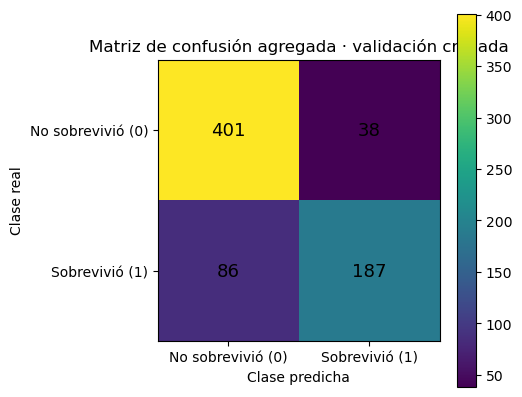

In [6]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

metricas_cv_rows = []
matrices_cv_rows = []
balance_cv_rows = []
advertencias_cv_rows = []

oof_pred = pd.Series(index=X_train.index, dtype='float64')
oof_prob = pd.Series(index=X_train.index, dtype='float64')
oof_fold = pd.Series(index=X_train.index, dtype='float64')

tiempo_cv_inicio = time.perf_counter()

for fold, (idx_train, idx_val) in enumerate(cv.split(X_train, y_train), start=1):
    X_fold_train = X_train.iloc[idx_train]
    X_fold_val = X_train.iloc[idx_val]
    y_fold_train = y_train.iloc[idx_train]
    y_fold_val = y_train.iloc[idx_val]

    if not set(X_fold_train.index).isdisjoint(set(X_fold_val.index)):
        raise RuntimeError(f'Existe solapamiento entre entrenamiento y validación en el fold {fold}.')

    pipeline_fold = construir_pipeline()
    inicio_ajuste = time.perf_counter()
    with warnings.catch_warnings(record=True) as advertencias:
        warnings.simplefilter('always')
        pipeline_fold.fit(X_fold_train, y_fold_train)
    tiempo_ajuste = time.perf_counter() - inicio_ajuste

    prob_val = probabilidad_clase_positiva(pipeline_fold, X_fold_val)
    pred_val = (prob_val >= UMBRAL_CLASIFICACION).astype(int)
    pred_val_sklearn = pipeline_fold.predict(X_fold_val)
    if not np.array_equal(pred_val, pred_val_sklearn):
        raise RuntimeError(f'El umbral explícito no coincide con predict() en el fold {fold}.')

    cm = confusion_matrix(y_fold_val, pred_val, labels=[NEG_LABEL, POS_LABEL])
    tn, fp, fn, tp = cm.ravel()
    especificidad = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan

    modelo_fold = pipeline_fold.named_steps['model']
    metricas_cv_rows.append({
        'Fold': fold,
        'N_train': len(idx_train),
        'N_validacion': len(idx_val),
        'Accuracy': accuracy_score(y_fold_val, pred_val),
        'Precision': precision_score(y_fold_val, pred_val, pos_label=POS_LABEL, zero_division=0),
        'Recall': recall_score(y_fold_val, pred_val, pos_label=POS_LABEL, zero_division=0),
        'F1_score': f1_score(y_fold_val, pred_val, pos_label=POS_LABEL, zero_division=0),
        'Balanced_accuracy': balanced_accuracy_score(y_fold_val, pred_val),
        'Especificidad': especificidad,
        'FPR': fpr,
        'FNR': fnr,
        'ROC_AUC': roc_auc_score(y_fold_val, prob_val),
        'Average_precision': average_precision_score(y_fold_val, prob_val),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'Iteraciones_MLP': int(modelo_fold.n_iter_),
        'Best_validation_score': float(getattr(modelo_fold, 'best_validation_score_', np.nan)),
        'Loss_final': float(modelo_fold.loss_),
        'Tiempo_ajuste_segundos': tiempo_ajuste,
    })

    for i, clase_real in enumerate([NEG_LABEL, POS_LABEL]):
        matrices_cv_rows.append({
            'Fold': fold,
            'Clase_real': int(clase_real),
            'Pred_0': int(cm[i, 0]),
            'Pred_1': int(cm[i, 1]),
        })

    balance_cv_rows.extend([
        {'Fold': fold, 'Particion_fold':'train', 'N':len(y_fold_train), 'Proporcion_clase_1':float(y_fold_train.mean())},
        {'Fold': fold, 'Particion_fold':'validacion', 'N':len(y_fold_val), 'Proporcion_clase_1':float(y_fold_val.mean())},
    ])

    for advertencia in advertencias:
        advertencias_cv_rows.append({
            'Fold': fold,
            'Categoria': advertencia.category.__name__,
            'Mensaje': str(advertencia.message),
        })

    oof_pred.loc[X_fold_val.index] = pred_val
    oof_prob.loc[X_fold_val.index] = prob_val
    oof_fold.loc[X_fold_val.index] = fold

tiempo_cv_total = time.perf_counter() - tiempo_cv_inicio

if oof_pred.isna().any() or oof_prob.isna().any() or oof_fold.isna().any():
    raise RuntimeError('Existen observaciones de entrenamiento sin predicción out-of-fold.')

metricas_cv = pd.DataFrame(metricas_cv_rows)
matrices_cv = pd.DataFrame(matrices_cv_rows)
balance_cv = pd.DataFrame(balance_cv_rows)
advertencias_cv = pd.DataFrame(advertencias_cv_rows, columns=['Fold', 'Categoria', 'Mensaje'])

oof_resultados = pd.DataFrame({
    'Indice_original': X_train.index,
    'Fold': oof_fold.loc[X_train.index].astype(int).values,
    'y_real': y_train.loc[X_train.index].values,
    'y_pred': oof_pred.loc[X_train.index].astype(int).values,
    'prob_clase_1': oof_prob.loc[X_train.index].values,
}).sort_values('Indice_original')

metricas_estabilidad = [
    'Accuracy', 'Precision', 'Recall', 'F1_score',
    'Balanced_accuracy', 'Especificidad', 'FPR', 'FNR',
    'ROC_AUC', 'Average_precision'
]
resumen_cv = pd.DataFrame([
    {
        'Metrica': metrica,
        'Promedio': metricas_cv[metrica].mean(),
        'Desv_estandar_poblacional': metricas_cv[metrica].std(ddof=0),
        'Desv_estandar_muestral': metricas_cv[metrica].std(ddof=1),
        'Minimo': metricas_cv[metrica].min(),
        'Maximo': metricas_cv[metrica].max(),
        'Rango': metricas_cv[metrica].max() - metricas_cv[metrica].min(),
    }
    for metrica in metricas_estabilidad
])

cm_cv_agregada = confusion_matrix(
    oof_resultados['y_real'], oof_resultados['y_pred'], labels=[NEG_LABEL, POS_LABEL]
)
cm_cv_agregada_df = pd.DataFrame(
    cm_cv_agregada,
    index=['Real_0_no_sobrevivio', 'Real_1_sobrevivio'],
    columns=['Pred_0_no_sobrevivio', 'Pred_1_sobrevivio'],
)

costo_validacion = pd.DataFrame([
    {'Indicador':'Ajustes_externos_KFold', 'Valor':N_SPLITS, 'Unidad':'ajustes'},
    {'Indicador':'Tiempo_total_KFold', 'Valor':tiempo_cv_total, 'Unidad':'segundos'},
    {'Indicador':'Tiempo_promedio_ajuste_fold', 'Valor':metricas_cv['Tiempo_ajuste_segundos'].mean(), 'Unidad':'segundos'},
    {'Indicador':'Ajustes_teoricos_LOOCV', 'Valor':len(X_train), 'Unidad':'ajustes'},
    {'Indicador':'Ajustes_HoldOut', 'Valor':1, 'Unidad':'ajustes'},
])

metricas_cv.to_csv(OUT_DIR / '14_metricas_cv_por_fold.csv', index=False)
resumen_cv.to_csv(OUT_DIR / '15_resumen_estabilidad_cv.csv', index=False)
matrices_cv.to_csv(OUT_DIR / '16_matrices_confusion_cv_por_fold.csv', index=False)
cm_cv_agregada_df.to_csv(OUT_DIR / '17_matriz_confusion_cv_agregada.csv')
oof_resultados.to_csv(OUT_DIR / '18_predicciones_oof_cv.csv', index=False)
balance_cv.to_csv(OUT_DIR / '19_balance_clases_cv.csv', index=False)
advertencias_cv.to_csv(OUT_DIR / '20_advertencias_cv.csv', index=False)
costo_validacion.to_csv(OUT_DIR / '21_costo_validacion.csv', index=False)

display(metricas_cv)
display(resumen_cv)
display(cm_cv_agregada_df)
display(costo_validacion)

fig, ax = plt.subplots(figsize=(8.2, 4.8))
barras = ax.bar(metricas_cv['Fold'].astype(str), metricas_cv['Accuracy'])
ax.axhline(metricas_cv['Accuracy'].mean(), linestyle='--', linewidth=1.5, label='Promedio')
for barra, valor in zip(barras, metricas_cv['Accuracy']):
    ax.text(barra.get_x() + barra.get_width()/2, valor, f'{valor:.3f}', ha='center', va='bottom', fontsize=8)
ax.set(title='Accuracy por fold · K-Fold estratificado', xlabel='Fold', ylabel='Accuracy', ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '02_accuracy_por_fold.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for metrica in ['Accuracy', 'Precision', 'Recall', 'F1_score']:
    ax.plot(metricas_cv['Fold'], metricas_cv[metrica], marker='o', label=metrica)
ax.set(title='Estabilidad de métricas por fold', xlabel='Fold', ylabel='Valor', xticks=metricas_cv['Fold'], ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '03_estabilidad_metricas_cv.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5.3, 4.5))
im = ax.imshow(cm_cv_agregada)
for (i, j), valor in np.ndenumerate(cm_cv_agregada):
    ax.text(j, i, str(valor), ha='center', va='center', fontsize=13)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'])
ax.set_yticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'])
ax.set(title='Matriz de confusión agregada · validación cruzada', xlabel='Clase predicha', ylabel='Clase real')
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_matriz_confusion_cv_agregada.png', dpi=180, bbox_inches='tight')
plt.show()


## 6. Evaluación Hold-Out del modelo seleccionado

El modelo se ajusta sobre el conjunto de entrenamiento completo y se evalúa sobre la partición Hold-Out histórica. Se calculan las métricas obligatorias, las métricas complementarias, la matriz de confusión, los tipos de error, el reporte por clase y las curvas ROC y Precision-Recall. El umbral se mantiene en `0.50` y no se optimiza con el conjunto de prueba.


,Modelo,N_test,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,FPR,FNR,...,FP,FN,TP,Umbral,Iteraciones,Detencion_antes_max_iter,Best_validation_score,Loss_final,Parametros_entrenables,Tiempo_ajuste_segundos
0,MLP 2 capas ocultas,179,0.793296,0.735294,0.724638,0.729927,0.780501,0.836364,0.163636,0.275362,...,18,19,50,0.5,52,True,0.878505,0.404834,6001,0.264772


,Pred_0_no_sobrevivio,Pred_1_sobrevivio
Real_0_no_sobrevivio,92,18
Real_1_sobrevivio,19,50


,Clase_o_resumen,Precision,Recall,F1_score,Support
0,No_sobrevivio_0,0.828829,0.836364,0.832579,110
1,Sobrevivio_1,0.735294,0.724638,0.729927,69
2,macro avg,0.782061,0.780501,0.781253,179
3,weighted avg,0.792774,0.793296,0.793009,179


,Control,Valor
0,Predictores_transformados,8
1,NaN_train_transformado,0
2,NaN_test_transformado,0
3,Filas_train_transformado,712
4,Filas_test_transformado,179


,Elemento,Valor
0,Clase_positiva,1
1,Umbral,0.5
2,Optimizado_con_test,False
3,Criterio,Continuidad con Semana 3 y ausencia de una fun...
4,Coincide_con_predict_sklearn,True


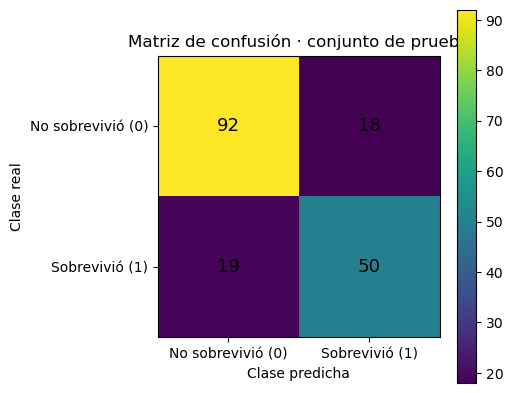

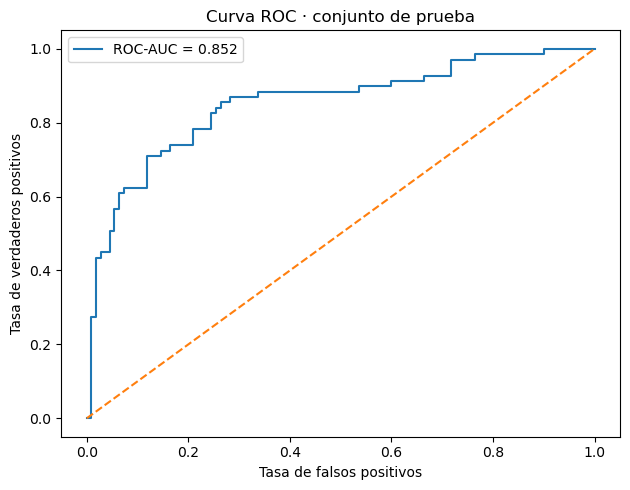

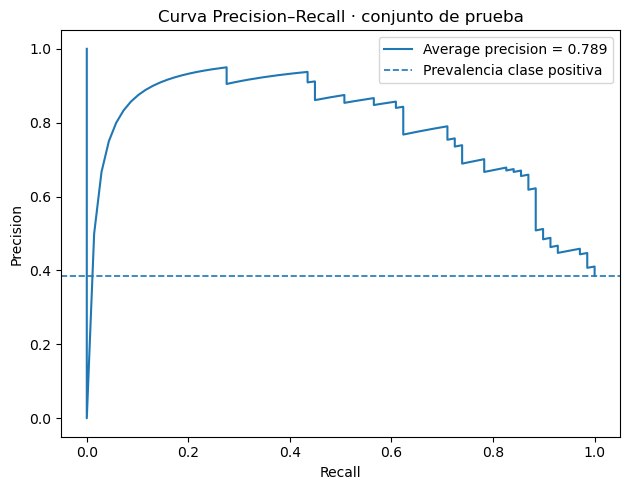

In [7]:
pipeline_final = construir_pipeline()
inicio_ajuste = time.perf_counter()
with warnings.catch_warnings(record=True) as advertencias_finales:
    warnings.simplefilter('always')
    pipeline_final.fit(X_train, y_train)
tiempo_ajuste_final = time.perf_counter() - inicio_ajuste

prob_test = probabilidad_clase_positiva(pipeline_final, X_test)
pred_test = (prob_test >= UMBRAL_CLASIFICACION).astype(int)
pred_test_sklearn = pipeline_final.predict(X_test)
if not np.array_equal(pred_test, pred_test_sklearn):
    raise RuntimeError('El umbral explícito no coincide con predict() en el conjunto de prueba.')

cm_test = confusion_matrix(y_test, pred_test, labels=[NEG_LABEL, POS_LABEL])
tn, fp, fn, tp = cm_test.ravel()
especificidad_test = tn / (tn + fp) if (tn + fp) else np.nan
fpr_test = fp / (fp + tn) if (fp + tn) else np.nan
fnr_test = fn / (fn + tp) if (fn + tp) else np.nan

modelo_final = pipeline_final.named_steps['model']
parametros_entrenables = int(
    sum(w.size for w in modelo_final.coefs_) +
    sum(b.size for b in modelo_final.intercepts_)
)

metricas_holdout = pd.DataFrame([{
    'Modelo': MODELO_SELECCIONADO,
    'N_test': len(y_test),
    'Accuracy': accuracy_score(y_test, pred_test),
    'Precision': precision_score(y_test, pred_test, pos_label=POS_LABEL, zero_division=0),
    'Recall': recall_score(y_test, pred_test, pos_label=POS_LABEL, zero_division=0),
    'F1_score': f1_score(y_test, pred_test, pos_label=POS_LABEL, zero_division=0),
    'Balanced_accuracy': balanced_accuracy_score(y_test, pred_test),
    'Especificidad': especificidad_test,
    'FPR': fpr_test,
    'FNR': fnr_test,
    'ROC_AUC': roc_auc_score(y_test, prob_test),
    'Average_precision': average_precision_score(y_test, prob_test),
    'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    'Umbral': UMBRAL_CLASIFICACION,
    'Iteraciones': int(modelo_final.n_iter_),
    'Detencion_antes_max_iter': bool(modelo_final.n_iter_ < MODEL_PARAMS['max_iter']),
    'Best_validation_score': float(getattr(modelo_final, 'best_validation_score_', np.nan)),
    'Loss_final': float(modelo_final.loss_),
    'Parametros_entrenables': parametros_entrenables,
    'Tiempo_ajuste_segundos': tiempo_ajuste_final,
}])

cm_test_df = pd.DataFrame(
    cm_test,
    index=['Real_0_no_sobrevivio', 'Real_1_sobrevivio'],
    columns=['Pred_0_no_sobrevivio', 'Pred_1_sobrevivio'],
)

tipo_resultado = np.select(
    [
        (y_test.to_numpy() == 0) & (pred_test == 0),
        (y_test.to_numpy() == 0) & (pred_test == 1),
        (y_test.to_numpy() == 1) & (pred_test == 0),
        (y_test.to_numpy() == 1) & (pred_test == 1),
    ],
    ['TN', 'FP', 'FN', 'TP'],
    default='NA',
)

predicciones_test = X_test.copy()
predicciones_test.insert(0, 'Indice_original', X_test.index)
predicciones_test['y_real'] = y_test.to_numpy()
predicciones_test['y_pred'] = pred_test
predicciones_test['prob_clase_1'] = prob_test
predicciones_test['Tipo_resultado'] = tipo_resultado
predicciones_test = predicciones_test.sort_values('Indice_original')

errores_holdout = predicciones_test.loc[predicciones_test['Tipo_resultado'].isin(['FP', 'FN'])].copy()

reporte_dict = classification_report(
    y_test,
    pred_test,
    labels=[NEG_LABEL, POS_LABEL],
    target_names=['No_sobrevivio_0', 'Sobrevivio_1'],
    output_dict=True,
    zero_division=0,
)
filas_reporte = ['No_sobrevivio_0', 'Sobrevivio_1', 'macro avg', 'weighted avg']
reporte_clasificacion = pd.DataFrame([
    {
        'Clase_o_resumen': fila,
        'Precision': float(reporte_dict[fila]['precision']),
        'Recall': float(reporte_dict[fila]['recall']),
        'F1_score': float(reporte_dict[fila]['f1-score']),
        'Support': int(reporte_dict[fila]['support']),
    }
    for fila in filas_reporte
])

if int(reporte_clasificacion.loc[
    reporte_clasificacion['Clase_o_resumen'].isin(['No_sobrevivio_0', 'Sobrevivio_1']),
    'Support',
].sum()) != len(y_test):
    raise RuntimeError('El soporte del reporte de clasificación no coincide con el tamaño del conjunto de prueba.')

feature_names = pipeline_final.named_steps['preprocessor'].get_feature_names_out()
X_train_transformado = pipeline_final.named_steps['preprocessor'].transform(X_train)
X_test_transformado = pipeline_final.named_steps['preprocessor'].transform(X_test)
control_preprocesamiento = pd.DataFrame([
    {'Control':'Predictores_transformados', 'Valor':len(feature_names)},
    {'Control':'NaN_train_transformado', 'Valor':int(np.isnan(X_train_transformado).sum())},
    {'Control':'NaN_test_transformado', 'Valor':int(np.isnan(X_test_transformado).sum())},
    {'Control':'Filas_train_transformado', 'Valor':X_train_transformado.shape[0]},
    {'Control':'Filas_test_transformado', 'Valor':X_test_transformado.shape[0]},
])

advertencias_holdout = pd.DataFrame([
    {'Categoria': advertencia.category.__name__, 'Mensaje': str(advertencia.message)}
    for advertencia in advertencias_finales
], columns=['Categoria', 'Mensaje'])

control_umbral = pd.DataFrame([
    {'Elemento':'Clase_positiva', 'Valor':POS_LABEL},
    {'Elemento':'Umbral', 'Valor':UMBRAL_CLASIFICACION},
    {'Elemento':'Optimizado_con_test', 'Valor':False},
    {'Elemento':'Criterio', 'Valor':'Continuidad con Semana 3 y ausencia de una función de costos definida'},
    {'Elemento':'Coincide_con_predict_sklearn', 'Valor':bool(np.array_equal(pred_test, pred_test_sklearn))},
])

metricas_holdout.to_csv(OUT_DIR / '22_metricas_holdout.csv', index=False)
cm_test_df.to_csv(OUT_DIR / '23_matriz_confusion_holdout.csv')
predicciones_test.to_csv(OUT_DIR / '24_predicciones_holdout.csv', index=False)
errores_holdout.to_csv(OUT_DIR / '25_errores_holdout.csv', index=False)
reporte_clasificacion.to_csv(OUT_DIR / '26_reporte_clasificacion_holdout.csv', index=False)
pd.DataFrame({'Variable_transformada': feature_names}).to_csv(OUT_DIR / '27_variables_transformadas.csv', index=False)
control_preprocesamiento.to_csv(OUT_DIR / '28_control_preprocesamiento.csv', index=False)
advertencias_holdout.to_csv(OUT_DIR / '29_advertencias_holdout.csv', index=False)
control_umbral.to_csv(OUT_DIR / '30_control_umbral.csv', index=False)

display(metricas_holdout)
display(cm_test_df)
display(reporte_clasificacion)
display(control_preprocesamiento)
display(control_umbral)

fig, ax = plt.subplots(figsize=(5.3, 4.5))
im = ax.imshow(cm_test)
for (i, j), valor in np.ndenumerate(cm_test):
    ax.text(j, i, str(valor), ha='center', va='center', fontsize=13)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'])
ax.set_yticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'])
ax.set(title='Matriz de confusión · conjunto de prueba', xlabel='Clase predicha', ylabel='Clase real')
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_matriz_confusion_holdout.png', dpi=180, bbox_inches='tight')
plt.show()

fpr_curve, tpr_curve, thresholds_roc = roc_curve(y_test, prob_test, pos_label=POS_LABEL)
roc_points = pd.DataFrame({
    'FPR': fpr_curve,
    'TPR': tpr_curve,
    'Threshold': thresholds_roc,
})
roc_points.to_csv(OUT_DIR / '31_puntos_curva_roc_holdout.csv', index=False)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.plot(fpr_curve, tpr_curve, label=f"ROC-AUC = {metricas_holdout.loc[0, 'ROC_AUC']:.3f}")
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set(title='Curva ROC · conjunto de prueba', xlabel='Tasa de falsos positivos', ylabel='Tasa de verdaderos positivos')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '06_curva_roc_holdout.png', dpi=180, bbox_inches='tight')
plt.show()

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, prob_test, pos_label=POS_LABEL)
pr_points = pd.DataFrame({
    'Precision': precision_curve,
    'Recall': recall_curve,
    'Threshold': np.append(thresholds_pr, np.nan),
})
pr_points.to_csv(OUT_DIR / '32_puntos_curva_precision_recall_holdout.csv', index=False)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.plot(recall_curve, precision_curve, label=f"Average precision = {metricas_holdout.loc[0, 'Average_precision']:.3f}")
ax.axhline(y_test.mean(), linestyle='--', linewidth=1.2, label='Prevalencia clase positiva')
ax.set(title='Curva Precision–Recall · conjunto de prueba', xlabel='Recall', ylabel='Precision')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '07_curva_precision_recall_holdout.png', dpi=180, bbox_inches='tight')
plt.show()


## 7. Continuidad numérica y comparación de protocolos

La corrida de Semana 4 se contrasta con las métricas y predicciones registradas de Semana 3 para el mismo modelo. La comparación entre Hold-Out y K-Fold se construye sin utilizar el conjunto de prueba para ajustar el modelo, el umbral o la técnica de validación.


,Metrica_o_control,Tipo_control,Valor_semana3,Valor_semana4,Diferencia_absoluta,Coincide
0,Accuracy,critico,0.793296,0.793296,0.0,True
1,Precision,critico,0.735294,0.735294,0.0,True
2,Recall,critico,0.724638,0.724638,0.0,True
3,F1_score,critico,0.729927,0.729927,0.0,True
4,Balanced_accuracy,critico,0.780501,0.780501,0.0,True
5,Especificidad,critico,0.836364,0.836364,0.0,True
6,TN,critico,92,92,0.0,True
7,FP,critico,18,18,0.0,True
8,FN,critico,19,19,0.0,True
9,TP,critico,50,50,0.0,True


,Control,Coincide,N_diferencias
0,y_real,True,0
1,y_pred_modelo_seleccionado,True,0


,Metrica,HoldOut_test,CV_promedio_train,CV_desv_estandar_poblacional,CV_desv_estandar_muestral,Diferencia_HoldOut_menos_CV
0,Accuracy,0.793296,0.825845,0.012062,0.013486,-0.032548
1,Precision,0.735294,0.834689,0.037326,0.041732,-0.099395
2,Recall,0.724638,0.684983,0.055066,0.061566,0.039655
3,F1_score,0.729927,0.749988,0.025877,0.028931,-0.020061
4,Balanced_accuracy,0.780501,0.799244,0.018063,0.020195,-0.018744
5,Especificidad,0.836364,0.913506,0.029151,0.032592,-0.077142
6,ROC_AUC,0.852174,0.862269,0.017722,0.019814,-0.010095
7,Average_precision,0.789082,0.839331,0.023534,0.026311,-0.050249


,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,ROC_AUC,Average_precision,TN,FP,FN,TP
0,0.825843,0.831111,0.684982,0.751004,0.799211,0.91344,0.856588,0.835323,401,38,86,187


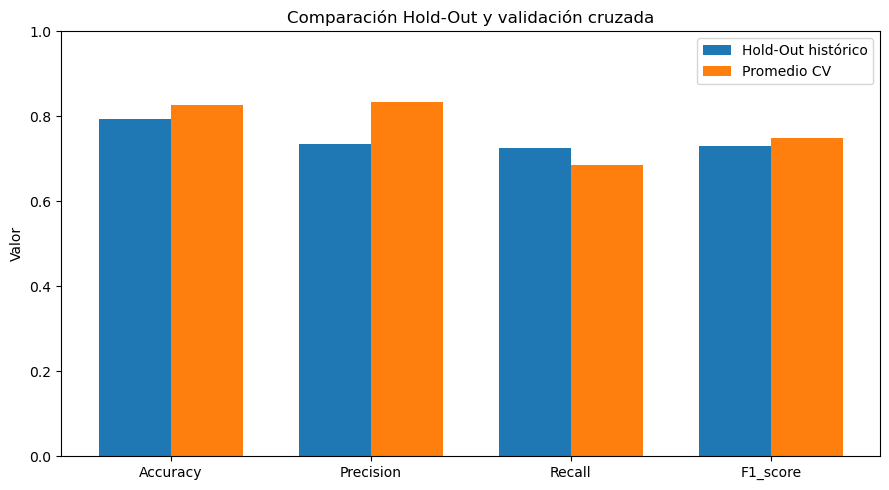

In [8]:
columnas_continuidad = {
    'Accuracy':'Accuracy',
    'Precision':'Precision',
    'Recall':'Recall',
    'F1_score':'F1_score',
    'Balanced_accuracy':'Balanced_accuracy',
    'Especificidad':'Especificidad',
    'TN':'TN', 'FP':'FP', 'FN':'FN', 'TP':'TP',
    'Iteraciones':'Iteraciones',
    'Detencion_antes_max_iter':'Detencion_antes_max_iter',
    'Best_validation_score':'Best_validation_score',
    'Loss_final':'Loss_final',
    'Parametros_entrenables':'Parametros_entrenables',
}

controles_criticos = {
    'Accuracy', 'Precision', 'Recall', 'F1_score', 'Balanced_accuracy',
    'Especificidad', 'TN', 'FP', 'FN', 'TP', 'Parametros_entrenables'
}

filas_continuidad = []
for metrica_s4, metrica_s3 in columnas_continuidad.items():
    valor_s3 = fila_metricas_s3.iloc[0][metrica_s3]
    valor_s4 = metricas_holdout.iloc[0][metrica_s4]

    if isinstance(valor_s4, (bool, np.bool_)):
        coincide = bool(valor_s4) == bool(valor_s3)
        diferencia = 0.0 if coincide else 1.0
    elif isinstance(valor_s4, (int, float, np.integer, np.floating)):
        diferencia = abs(float(valor_s4) - float(valor_s3))
        tolerancia = 1e-12 if metrica_s4 in controles_criticos else 1e-8
        coincide = bool(np.isclose(float(valor_s4), float(valor_s3), rtol=1e-10, atol=tolerancia))
    else:
        coincide = str(valor_s4) == str(valor_s3)
        diferencia = 0.0 if coincide else 1.0

    filas_continuidad.append({
        'Metrica_o_control': metrica_s4,
        'Tipo_control': 'critico' if metrica_s4 in controles_criticos else 'informativo',
        'Valor_semana3': valor_s3,
        'Valor_semana4': valor_s4,
        'Diferencia_absoluta': diferencia,
        'Coincide': coincide,
    })

continuidad_metricas = pd.DataFrame(filas_continuidad)
continuidad_metricas.to_csv(OUT_DIR / '33_verificacion_continuidad_metricas_semana3.csv', index=False)
if not continuidad_metricas.loc[continuidad_metricas['Tipo_control'] == 'critico', 'Coincide'].all():
    raise RuntimeError('Las métricas críticas Hold-Out no reproducen la evidencia archivada de Semana 3.')

predicciones_s3 = pd.read_csv(S3_PREDICTIONS)
if MODELO_SELECCIONADO not in predicciones_s3.columns:
    raise RuntimeError('La tabla de predicciones de Semana 3 no contiene el modelo seleccionado.')

continuidad_predicciones = pd.DataFrame([
    {
        'Control':'y_real',
        'Coincide':bool(np.array_equal(predicciones_s3['y_real'].to_numpy(), y_test.to_numpy())),
        'N_diferencias':int(np.sum(predicciones_s3['y_real'].to_numpy() != y_test.to_numpy())),
    },
    {
        'Control':'y_pred_modelo_seleccionado',
        'Coincide':bool(np.array_equal(predicciones_s3[MODELO_SELECCIONADO].to_numpy(), pred_test)),
        'N_diferencias':int(np.sum(predicciones_s3[MODELO_SELECCIONADO].to_numpy() != pred_test)),
    },
])
continuidad_predicciones.to_csv(OUT_DIR / '34_verificacion_continuidad_predicciones_semana3.csv', index=False)
if not continuidad_predicciones['Coincide'].all():
    raise RuntimeError('Las predicciones Hold-Out no coinciden con la evidencia archivada de Semana 3.')

comparacion_rows = []
for metrica in ['Accuracy', 'Precision', 'Recall', 'F1_score', 'Balanced_accuracy', 'Especificidad', 'ROC_AUC', 'Average_precision']:
    comparacion_rows.append({
        'Metrica': metrica,
        'HoldOut_test': float(metricas_holdout.iloc[0][metrica]),
        'CV_promedio_train': float(resumen_cv.loc[resumen_cv['Metrica'] == metrica, 'Promedio'].iloc[0]),
        'CV_desv_estandar_poblacional': float(resumen_cv.loc[resumen_cv['Metrica'] == metrica, 'Desv_estandar_poblacional'].iloc[0]),
        'CV_desv_estandar_muestral': float(resumen_cv.loc[resumen_cv['Metrica'] == metrica, 'Desv_estandar_muestral'].iloc[0]),
        'Diferencia_HoldOut_menos_CV': float(metricas_holdout.iloc[0][metrica]) - float(resumen_cv.loc[resumen_cv['Metrica'] == metrica, 'Promedio'].iloc[0]),
    })
comparacion_validacion = pd.DataFrame(comparacion_rows)
comparacion_validacion.to_csv(OUT_DIR / '35_comparacion_holdout_cv.csv', index=False)

cm_oof_recalculada = confusion_matrix(oof_resultados['y_real'], oof_resultados['y_pred'], labels=[NEG_LABEL, POS_LABEL])
tn_oof, fp_oof, fn_oof, tp_oof = cm_oof_recalculada.ravel()
metricas_oof = pd.DataFrame([{
    'Accuracy': accuracy_score(oof_resultados['y_real'], oof_resultados['y_pred']),
    'Precision': precision_score(oof_resultados['y_real'], oof_resultados['y_pred'], pos_label=POS_LABEL, zero_division=0),
    'Recall': recall_score(oof_resultados['y_real'], oof_resultados['y_pred'], pos_label=POS_LABEL, zero_division=0),
    'F1_score': f1_score(oof_resultados['y_real'], oof_resultados['y_pred'], pos_label=POS_LABEL, zero_division=0),
    'Balanced_accuracy': balanced_accuracy_score(oof_resultados['y_real'], oof_resultados['y_pred']),
    'Especificidad': tn_oof / (tn_oof + fp_oof),
    'ROC_AUC': roc_auc_score(oof_resultados['y_real'], oof_resultados['prob_clase_1']),
    'Average_precision': average_precision_score(oof_resultados['y_real'], oof_resultados['prob_clase_1']),
    'TN': int(tn_oof), 'FP': int(fp_oof), 'FN': int(fn_oof), 'TP': int(tp_oof),
}])
metricas_oof.to_csv(OUT_DIR / '36_metricas_oof_agregadas.csv', index=False)

display(continuidad_metricas)
display(continuidad_predicciones)
display(comparacion_validacion)
display(metricas_oof)

plot_df = comparacion_validacion[comparacion_validacion['Metrica'].isin(['Accuracy', 'Precision', 'Recall', 'F1_score'])].copy()
x = np.arange(len(plot_df))
ancho = 0.36
fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.bar(x - ancho/2, plot_df['HoldOut_test'], width=ancho, label='Hold-Out histórico')
ax.bar(x + ancho/2, plot_df['CV_promedio_train'], width=ancho, label='Promedio CV')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Metrica'])
ax.set_ylim(0, 1)
ax.set(title='Comparación Hold-Out y validación cruzada', ylabel='Valor')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '08_comparacion_holdout_cv.png', dpi=180, bbox_inches='tight')
plt.show()


## 8. Trazabilidad de rúbrica, controles y manifiesto

La celda final verifica consistencia numérica, integridad de las predicciones, ausencia de valores faltantes después del preprocesamiento, existencia de los artefactos generados y correspondencia entre notebook, repositorio y evidencias requeridas por la evaluación.


In [9]:
if not np.array_equal(cm_oof_recalculada, cm_cv_agregada):
    raise RuntimeError('La matriz agregada de CV no coincide con las predicciones out-of-fold.')
if int(cm_cv_agregada.sum()) != len(y_train):
    raise RuntimeError('La matriz agregada de CV no contiene todas las observaciones de entrenamiento.')
if int(cm_test.sum()) != len(y_test):
    raise RuntimeError('La matriz Hold-Out no contiene todas las observaciones de prueba.')
if not set(oof_resultados['Indice_original']).isdisjoint(set(X_test.index)):
    raise RuntimeError('Se detectaron observaciones de prueba dentro de las predicciones out-of-fold.')
if control_preprocesamiento.loc[control_preprocesamiento['Control'] == 'NaN_train_transformado', 'Valor'].iloc[0] != 0:
    raise RuntimeError('Se detectaron NaN después del preprocesamiento de entrenamiento.')
if control_preprocesamiento.loc[control_preprocesamiento['Control'] == 'NaN_test_transformado', 'Valor'].iloc[0] != 0:
    raise RuntimeError('Se detectaron NaN después del preprocesamiento de prueba.')
if len(oof_resultados) != len(y_train) or oof_resultados['Indice_original'].nunique() != len(y_train):
    raise RuntimeError('Las predicciones out-of-fold no cubren cada observación de entrenamiento exactamente una vez.')
if not np.isclose(
    metricas_holdout.loc[0, 'Accuracy'],
    (metricas_holdout.loc[0, 'TP'] + metricas_holdout.loc[0, 'TN']) / len(y_test),
):
    raise RuntimeError('La accuracy Hold-Out no coincide con la matriz de confusión.')

if 'accuracy' in set(reporte_clasificacion['Clase_o_resumen']):
    raise RuntimeError('El reporte detallado no debe representar accuracy como si fuera una fila de métricas por clase.')
if int(reporte_clasificacion.loc[
    reporte_clasificacion['Clase_o_resumen'].isin(['No_sobrevivio_0', 'Sobrevivio_1']),
    'Support',
].sum()) != len(y_test):
    raise RuntimeError('El soporte de las clases del reporte no coincide con el tamaño del conjunto de prueba.')

trazabilidad_rubrica = pd.DataFrame([
    {'Criterio':'C1 Evaluación del desempeño', 'Evidencia_notebook':'Secciones 2, 3, 4 y 6', 'Artefactos':'04_diccionario_variables.csv; 22_metricas_holdout.csv; 23_matriz_confusion_holdout.csv'},
    {'Criterio':'C2 Reporte tabulado de métricas', 'Evidencia_notebook':'Sección 6', 'Artefactos':'22_metricas_holdout.csv; 26_reporte_clasificacion_holdout.csv'},
    {'Criterio':'C3 Matriz de confusión y métricas', 'Evidencia_notebook':'Sección 6', 'Artefactos':'22_metricas_holdout.csv; 23_matriz_confusion_holdout.csv; figura 05'},
    {'Criterio':'C4 Interpretación del desempeño', 'Evidencia_notebook':'Evidencia cuantitativa para el informe', 'Artefactos':'24_predicciones_holdout.csv; 25_errores_holdout.csv; 22_metricas_holdout.csv'},
    {'Criterio':'C5 Toma de decisiones', 'Evidencia_notebook':'Evidencia cuantitativa para el informe', 'Artefactos':'30_control_umbral.csv; 35_comparacion_holdout_cv.csv; curvas ROC y PR'},
    {'Criterio':'C6 Notebook y trazabilidad de evaluación', 'Evidencia_notebook':'Flujo completo y control final', 'Artefactos':'00-40 outputs; figuras 01-08; manifiesto'},
    {'Criterio':'C7 Conclusiones del desempeño', 'Evidencia_notebook':'Evidencia cuantitativa para el informe', 'Artefactos':'22_metricas_holdout.csv; 25_errores_holdout.csv; 29_advertencias_holdout.csv'},
    {'Criterio':'C8 Estabilidad de métricas', 'Evidencia_notebook':'Sección 5', 'Artefactos':'14_metricas_cv_por_fold.csv; 15_resumen_estabilidad_cv.csv; figuras 02-04'},
    {'Criterio':'C9 Justificación de validación', 'Evidencia_notebook':'Sección 4 y costo observado', 'Artefactos':'13_protocolo_validacion.csv; 21_costo_validacion.csv'},
    {'Criterio':'C10 Coherencia metodológica', 'Evidencia_notebook':'Pipeline dentro de cada fold; CV solo en train', 'Artefactos':'10b_verificacion_split_semana3.csv; 12_configuracion_evaluacion.csv; 19_balance_clases_cv.csv; 28_control_preprocesamiento.csv'},
    {'Criterio':'C11 Notebook y trazabilidad de validación', 'Evidencia_notebook':'Sección 5 y control final', 'Artefactos':'14-21 outputs; 18_predicciones_oof_cv.csv; 39_manifiesto_artefactos.csv'},
    {'Criterio':'C12 Conclusiones de validación', 'Evidencia_notebook':'Evidencia cuantitativa para el informe', 'Artefactos':'15_resumen_estabilidad_cv.csv; 21_costo_validacion.csv; 35_comparacion_holdout_cv.csv'},
    {'Criterio':'C13 Portada e índice', 'Evidencia_notebook':'No corresponde al cuaderno', 'Artefactos':'Debe cubrirse en el informe final'},
    {'Criterio':'C14 Formato institucional', 'Evidencia_notebook':'No corresponde al cuaderno', 'Artefactos':'Debe cubrirse en el PDF final'},
    {'Criterio':'C15 Ortografía y gramática', 'Evidencia_notebook':'Nomenclatura y documentación técnica formal', 'Artefactos':'Revisión final del informe y notebook'},
    {'Criterio':'C16 Fuentes y referencias', 'Evidencia_notebook':'No sustituye la citación del informe', 'Artefactos':'Debe cubrirse en el informe final con fuentes requeridas'},
    {'Criterio':'C17 Anexos', 'Evidencia_notebook':'Tablas y figuras reproducibles', 'Artefactos':'Semana4/outputs/ y Semana4/figures/'},
])
trazabilidad_rubrica.to_csv(OUT_DIR / '37_trazabilidad_rubrica.csv', index=False)

metadata_ejecucion = {
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'n_splits': N_SPLITS,
    'tecnica_validacion': 'StratifiedKFold',
    'umbral_clasificacion': UMBRAL_CLASIFICACION,
    'clase_positiva': POS_LABEL,
    'modelo': MODELO_SELECCIONADO,
    'arquitectura': list(ARQUITECTURA_SELECCIONADA),
    'dataset_sha256': hash_s4,
    'n_total': int(len(clf_df)),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'versiones': versiones_actuales,
    'metricas_holdout': {
        metrica: float(metricas_holdout.iloc[0][metrica])
        for metrica in ['Accuracy', 'Precision', 'Recall', 'F1_score', 'Balanced_accuracy', 'Especificidad', 'ROC_AUC', 'Average_precision']
    },
    'resumen_cv': {
        fila['Metrica']: {
            'promedio': float(fila['Promedio']),
            'std_poblacional': float(fila['Desv_estandar_poblacional']),
            'std_muestral': float(fila['Desv_estandar_muestral']),
        }
        for _, fila in resumen_cv.iterrows()
    },
    'n_advertencias_cv': int(len(advertencias_cv)),
    'n_advertencias_holdout': int(len(advertencias_holdout)),
}
with open(OUT_DIR / '38_metadata_ejecucion.json', 'w', encoding='utf-8') as archivo:
    json.dump(metadata_ejecucion, archivo, ensure_ascii=False, indent=2)

required_data = ['titanic.csv']
required_outputs = [
    '00_versiones_entorno.csv',
    '01_control_versiones_semana3.csv',
    '02_verificacion_configuracion_semana3.csv',
    '03_proveniencia_semana3.csv',
    '04_diccionario_variables.csv',
    '05_perfil_dataset.csv',
    '06_control_nulos.csv',
    '07_distribucion_clases.csv',
    '08_dimensiones_split.csv',
    '09_balance_clases_split.csv',
    '10_indices_split.csv',
    '10b_verificacion_split_semana3.csv',
    '11_diccionario_metricas.csv',
    '12_configuracion_evaluacion.csv',
    '13_protocolo_validacion.csv',
    '14_metricas_cv_por_fold.csv',
    '15_resumen_estabilidad_cv.csv',
    '16_matrices_confusion_cv_por_fold.csv',
    '17_matriz_confusion_cv_agregada.csv',
    '18_predicciones_oof_cv.csv',
    '19_balance_clases_cv.csv',
    '20_advertencias_cv.csv',
    '21_costo_validacion.csv',
    '22_metricas_holdout.csv',
    '23_matriz_confusion_holdout.csv',
    '24_predicciones_holdout.csv',
    '25_errores_holdout.csv',
    '26_reporte_clasificacion_holdout.csv',
    '27_variables_transformadas.csv',
    '28_control_preprocesamiento.csv',
    '29_advertencias_holdout.csv',
    '30_control_umbral.csv',
    '31_puntos_curva_roc_holdout.csv',
    '32_puntos_curva_precision_recall_holdout.csv',
    '33_verificacion_continuidad_metricas_semana3.csv',
    '34_verificacion_continuidad_predicciones_semana3.csv',
    '35_comparacion_holdout_cv.csv',
    '36_metricas_oof_agregadas.csv',
    '37_trazabilidad_rubrica.csv',
    '38_metadata_ejecucion.json',
]
required_figures = [
    '01_distribucion_clases.png',
    '02_accuracy_por_fold.png',
    '03_estabilidad_metricas_cv.png',
    '04_matriz_confusion_cv_agregada.png',
    '05_matriz_confusion_holdout.png',
    '06_curva_roc_holdout.png',
    '07_curva_precision_recall_holdout.png',
    '08_comparacion_holdout_cv.png',
]

artefactos = []
for carpeta in (DATA_DIR, OUT_DIR, FIG_DIR):
    for archivo in sorted(carpeta.iterdir()):
        if archivo.is_file() and archivo.name not in {'.gitkeep', 'README.md', '39_manifiesto_artefactos.csv', '40_control_artefactos_requeridos.csv'}:
            artefactos.append({
                'Ruta': archivo.relative_to(ROOT).as_posix(),
                'Bytes': archivo.stat().st_size,
                'SHA256': sha256_archivo(archivo),
            })
manifiesto = pd.DataFrame(artefactos)
manifiesto.to_csv(OUT_DIR / '39_manifiesto_artefactos.csv', index=False)

checks = []
for nombre in required_data:
    archivo = DATA_DIR / nombre
    checks.append({'Tipo':'data', 'Archivo':nombre, 'Existe':archivo.exists(), 'Bytes':archivo.stat().st_size if archivo.exists() else 0})
for nombre in required_outputs + ['39_manifiesto_artefactos.csv']:
    archivo = OUT_DIR / nombre
    checks.append({'Tipo':'output', 'Archivo':nombre, 'Existe':archivo.exists(), 'Bytes':archivo.stat().st_size if archivo.exists() else 0})
for nombre in required_figures:
    archivo = FIG_DIR / nombre
    checks.append({'Tipo':'figure', 'Archivo':nombre, 'Existe':archivo.exists(), 'Bytes':archivo.stat().st_size if archivo.exists() else 0})

control_artefactos = pd.DataFrame(checks)
control_artefactos.to_csv(OUT_DIR / '40_control_artefactos_requeridos.csv', index=False)
faltantes = control_artefactos.loc[~control_artefactos['Existe'], 'Archivo'].tolist()
if faltantes:
    raise RuntimeError('Faltan artefactos requeridos: ' + ', '.join(faltantes))

if not continuidad_metricas.loc[continuidad_metricas['Tipo_control'] == 'critico', 'Coincide'].all() or not continuidad_predicciones['Coincide'].all():
    raise RuntimeError('La continuidad crítica con Semana 3 no fue validada completamente.')

if not control_split_semana3['Coincide'].all():
    raise RuntimeError('La partición no coincide con Semana 3.')

if not control_configuracion['Coincide_semana3'].all():
    raise RuntimeError('La configuración del modelo no coincide con Semana 3.')

if not control_umbral.loc[control_umbral['Elemento'] == 'Coincide_con_predict_sklearn', 'Valor'].iloc[0]:
    raise RuntimeError('El control del umbral no coincide con predict() de scikit-learn.')

display(trazabilidad_rubrica)
display(control_artefactos)
print('Control final de consistencia: OK')
print('Continuidad con Semana 3: OK')
print('Artefactos requeridos: OK')


,Criterio,Evidencia_notebook,Artefactos
0,C1 Evaluación del desempeño,"Secciones 2, 3, 4 y 6",04_diccionario_variables.csv; 22_metricas_hold...
1,C2 Reporte tabulado de métricas,Sección 6,22_metricas_holdout.csv; 26_reporte_clasificac...
2,C3 Matriz de confusión y métricas,Sección 6,22_metricas_holdout.csv; 23_matriz_confusion_h...
3,C4 Interpretación del desempeño,Evidencia cuantitativa para el informe,24_predicciones_holdout.csv; 25_errores_holdou...
4,C5 Toma de decisiones,Evidencia cuantitativa para el informe,30_control_umbral.csv; 35_comparacion_holdout_...
5,C6 Notebook y trazabilidad de evaluación,Flujo completo y control final,00-40 outputs; figuras 01-08; manifiesto
6,C7 Conclusiones del desempeño,Evidencia cuantitativa para el informe,22_metricas_holdout.csv; 25_errores_holdout.cs...
7,C8 Estabilidad de métricas,Sección 5,14_metricas_cv_por_fold.csv; 15_resumen_estabi...
8,C9 Justificación de validación,Sección 4 y costo observado,13_protocolo_validacion.csv; 21_costo_validaci...
9,C10 Coherencia metodológica,Pipeline dentro de cada fold; CV solo en train,10b_verificacion_split_semana3.csv; 12_configu...


,Tipo,Archivo,Existe,Bytes
0,data,titanic.csv,True,57018
1,output,00_versiones_entorno.csv,True,101
2,output,01_control_versiones_semana3.csv,True,190
3,output,02_verificacion_configuracion_semana3.csv,True,271
4,output,03_proveniencia_semana3.csv,True,272
5,output,04_diccionario_variables.csv,True,1300
6,output,05_perfil_dataset.csv,True,234
7,output,06_control_nulos.csv,True,104
8,output,07_distribucion_clases.csv,True,79
9,output,08_dimensiones_split.csv,True,64


Control final de consistencia: OK
Continuidad con Semana 3: OK
Artefactos requeridos: OK
